# LSE | Insight Nexus x Bank of England - Master notebook

This notebook contains all of the code used to conduct the full end to end analysis of the project. It includes visualisations and describes the justifications behind them with clear markdowns in-between code blocks. Each group of blocks is defined with headings and sub-headings and cover the following topics:
- Preliminary sentiment analysis using the Loughran McDonald (LM) dictionary
- (TBD) VADER sentiment analysis of speeches dataset
- FinBERT sentiment analysis of speeches dataset
- Financial Stability, Inflation and Monetary Policy Report sentiment analysis using LM and VADER


In [4]:
# Import necessary libraries.
# Creating the linear regression
import numpy as np
import pandas as pd
import pylab as py
import sklearn
from datetime import datetime
import re
import os

# Visualise the linear regression.
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as scipy
from scipy import stats
from sklearn import metrics
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.stats.api as sms
from statsmodels.graphics.gofplots import qqplot

# Import the statsmodels.
import statsmodels.api as sm 
from statsmodels.formula.api import ols

# Import nltk libraries
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('words')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.corpus import words
from nltk.tokenize import word_tokenize
from nltk.probability import FreqDist
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob
stop_words = set(stopwords.words('english'))
# TEST

[nltk_data] Downloading package punkt to /Users/sarah/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/sarah/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package words to /Users/sarah/nltk_data...
[nltk_data]   Package words is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /Users/sarah/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## **Preliminary sentiment analysis** - Sentiment (using the Loughran–McDonald Dictionary) vs Key Variables

***

#### Outputs from this section:

In [5]:
# Load the CSV file(s) as reviews.
variables = pd.read_csv('../data_clean/variables.csv')  

# Print the DataFrame.
variables.head() 

,Month / Year,Average Compound,Average Polarity,Average Subjectivity,Average lm_score,EOM,VALUES,VLOOKUP,check,UK Core inflation (%),UK Unemployment (%),UK Average Weekly earnings growth (%),UK GDP growth (%),UK benchmark rate (%),UK Economic Inactivity rate (%),UK house price index mom (%)
0,Sep-98,0.992500,0.083288,0.435206,-0.212121,Sep-98,Sep-98,Sep-98,True,1.3,6.2,NaN,0.1,7.50,23.6,0.3
1,Oct-98,0.999150,0.084071,0.381859,-0.163729,Oct-98,Oct-98,Oct-98,True,1.2,6.2,NaN,0.5,7.50,23.6,1.0
2,Nov-98,0.998033,0.081633,0.429144,-0.316236,Nov-98,Nov-98,Nov-98,True,1.1,6.1,NaN,0.2,7.25,23.5,-0.1
3,Dec-98,0.999400,0.079172,0.411767,-0.348099,Dec-98,Dec-98,Dec-98,True,1.2,6.2,NaN,0.3,6.75,23.5,-0.2
4,Jan-99,0.997600,0.086975,0.395355,-0.266017,Jan-99,Jan-99,Jan-99,True,1.2,6.2,NaN,0.2,6.25,23.3,0.7


In [6]:
# Replace the missing values with 0 (if applicable)
variables.fillna(0, inplace=True)

In [7]:
# Print the DataFrame.
variables.head() 

,Month / Year,Average Compound,Average Polarity,Average Subjectivity,Average lm_score,EOM,VALUES,VLOOKUP,check,UK Core inflation (%),UK Unemployment (%),UK Average Weekly earnings growth (%),UK GDP growth (%),UK benchmark rate (%),UK Economic Inactivity rate (%),UK house price index mom (%)
0,Sep-98,0.992500,0.083288,0.435206,-0.212121,Sep-98,Sep-98,Sep-98,True,1.3,6.2,0.0,0.1,7.50,23.6,0.3
1,Oct-98,0.999150,0.084071,0.381859,-0.163729,Oct-98,Oct-98,Oct-98,True,1.2,6.2,0.0,0.5,7.50,23.6,1.0
2,Nov-98,0.998033,0.081633,0.429144,-0.316236,Nov-98,Nov-98,Nov-98,True,1.1,6.1,0.0,0.2,7.25,23.5,-0.1
3,Dec-98,0.999400,0.079172,0.411767,-0.348099,Dec-98,Dec-98,Dec-98,True,1.2,6.2,0.0,0.3,6.75,23.5,-0.2
4,Jan-99,0.997600,0.086975,0.395355,-0.266017,Jan-99,Jan-99,Jan-99,True,1.2,6.2,0.0,0.2,6.25,23.3,0.7


In [8]:
# Determine the number of missing values.
variables.isna().sum()

Month / Year                             0
Average Compound                         0
Average Polarity                         0
Average Subjectivity                     0
Average lm_score                         0
EOM                                      0
VALUES                                   0
VLOOKUP                                  0
check                                    0
UK Core inflation (%)                    0
UK Unemployment (%)                      0
UK Average Weekly earnings growth (%)    0
UK GDP growth (%)                        0
UK benchmark rate (%)                    0
UK Economic Inactivity rate (%)          0
UK house price index mom (%)             0
dtype: int64

In [9]:
# View the metadata.
variables.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 16 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Month / Year                           272 non-null    object 
 1   Average Compound                       272 non-null    float64
 2   Average Polarity                       272 non-null    float64
 3   Average Subjectivity                   272 non-null    float64
 4   Average lm_score                       272 non-null    float64
 5   EOM                                    272 non-null    object 
 6   VALUES                                 272 non-null    object 
 7   VLOOKUP                                272 non-null    object 
 8   check                                  272 non-null    object 
 9   UK Core inflation (%)                  272 non-null    float64
 10  UK Unemployment (%)                    272 non-null    float64
 11  UK Ave

In [10]:
# Basic descriptive statistics.
variables.describe()

,Average Compound,Average Polarity,Average Subjectivity,Average lm_score,UK Core inflation (%),UK Unemployment (%),UK Average Weekly earnings growth (%),UK GDP growth (%),UK benchmark rate (%),UK Economic Inactivity rate (%),UK house price index mom (%)
count,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000,272.000000
mean,0.759256,0.094863,0.413387,-0.175729,1.797059,5.605147,2.722426,0.148162,2.299265,22.495956,0.497426
std,0.382848,0.016664,0.020909,0.165373,1.061534,1.378181,1.928896,1.584145,2.260670,1.618557,0.801171
min,-0.999300,0.041209,0.324390,-0.654952,-0.100000,0.000000,-2.900000,-19.200000,0.000000,0.000000,-2.500000
25%,0.603565,0.084715,0.402782,-0.276640,1.200000,4.700000,1.300000,-0.100000,0.500000,21.800000,0.000000
50%,0.995075,0.093557,0.414254,-0.191604,1.600000,5.200000,2.700000,0.200000,0.750000,22.900000,0.500000
75%,0.999243,0.103759,0.425500,-0.081818,2.100000,6.200000,4.200000,0.500000,4.562500,23.300000,1.000000
max,0.999900,0.161252,0.484238,0.321495,6.500000,8.500000,8.900000,9.300000,7.500000,23.600000,2.800000


### Remove & rename columns

In [11]:
# Drop unnecessary columns

variables.drop(columns=['Average Compound', 'Average Polarity', 'Average Subjectivity', 'EOM', 'VALUES', 'VLOOKUP', 'check'], 
               inplace=True)

# Rename the column headers

variables.rename(columns={
    'Average lm_score': 'Sentiment_LM',
    'UK Core inflation (%)' : 'Inflation_Core',
    'UK Unemployment (%)': 'Unemployment',
    'UK Average Weekly earnings growth (%)' : 'Wages_growth',
    'UK GDP growth (%)' : 'GDP_growth',
    'UK benchmark rate (%)' : 'Benchmark_rate',
    'UK Economic Inactivity rate (%)' : 'Economic_Inactivity_rate',
    'UK house price index mom (%)' : 'House_price_index'
}, inplace=True)

# View column names
variables.columns

Index(['Month / Year', 'Sentiment_LM', 'Inflation_Core', 'Unemployment',
       'Wages_growth', 'GDP_growth', 'Benchmark_rate',
       'Economic_Inactivity_rate', 'House_price_index'],
      dtype='object')

In [12]:
# View the dataframe
variables.head()

,Month / Year,Sentiment_LM,Inflation_Core,Unemployment,Wages_growth,GDP_growth,Benchmark_rate,Economic_Inactivity_rate,House_price_index
0,Sep-98,-0.212121,1.3,6.2,0.0,0.1,7.50,23.6,0.3
1,Oct-98,-0.163729,1.2,6.2,0.0,0.5,7.50,23.6,1.0
2,Nov-98,-0.316236,1.1,6.1,0.0,0.2,7.25,23.5,-0.1
3,Dec-98,-0.348099,1.2,6.2,0.0,0.3,6.75,23.5,-0.2
4,Jan-99,-0.266017,1.2,6.2,0.0,0.2,6.25,23.3,0.7


### Save the DataFrame as a CSV file

In [15]:
# Create a CSV file as output.
variables.to_csv('../data_clean/variables_clean.csv', index=False)

In [16]:
# Import new CSV file with Pandas.
variables_clean = pd.read_csv('../data_clean/variables_clean.csv')

# View DataFrame.
variables_clean.head() 

,Month / Year,Sentiment_LM,Inflation_Core,Unemployment,Wages_growth,GDP_growth,Benchmark_rate,Economic_Inactivity_rate,House_price_index
0,Sep-98,-0.212121,1.3,6.2,0.0,0.1,7.50,23.6,0.3
1,Oct-98,-0.163729,1.2,6.2,0.0,0.5,7.50,23.6,1.0
2,Nov-98,-0.316236,1.1,6.1,0.0,0.2,7.25,23.5,-0.1
3,Dec-98,-0.348099,1.2,6.2,0.0,0.3,6.75,23.5,-0.2
4,Jan-99,-0.266017,1.2,6.2,0.0,0.2,6.25,23.3,0.7


In [17]:
# Check metadata
variables_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 272 entries, 0 to 271
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Month / Year              272 non-null    object 
 1   Sentiment_LM              272 non-null    float64
 2   Inflation_Core            272 non-null    float64
 3   Unemployment              272 non-null    float64
 4   Wages_growth              272 non-null    float64
 5   GDP_growth                272 non-null    float64
 6   Benchmark_rate            272 non-null    float64
 7   Economic_Inactivity_rate  272 non-null    float64
 8   House_price_index         272 non-null    float64
dtypes: float64(8), object(1)
memory usage: 19.3+ KB


In [18]:
# Check shape
variables_clean.shape

(272, 9)

### Determine Correlation 

In [23]:
# Determine correlation
variables_clean.corr(numeric_only=True) # Edited code here to only user numeric columns otherwise I got a type error)

,Sentiment_LM,Inflation_Core,Unemployment,Wages_growth,GDP_growth,Benchmark_rate,Economic_Inactivity_rate,House_price_index
Sentiment_LM,1.000000,-0.229423,-0.353744,0.116285,-0.047610,0.184597,-0.055428,0.142878
Inflation_Core,-0.229423,1.000000,0.106526,0.309099,-0.007420,-0.454871,-0.013902,-0.178638
Unemployment,-0.353744,0.106526,1.000000,-0.431224,0.014675,-0.147660,0.478248,-0.149473
Wages_growth,0.116285,0.309099,-0.431224,1.000000,-0.024000,0.126611,0.030629,0.061977
GDP_growth,-0.047610,-0.007420,0.014675,-0.024000,1.000000,0.001329,0.020642,0.120786
Benchmark_rate,0.184597,-0.454871,-0.147660,0.126611,0.001329,1.000000,0.390476,0.159392
Economic_Inactivity_rate,-0.055428,-0.013902,0.478248,0.030629,0.020642,0.390476,1.000000,0.097568
House_price_index,0.142878,-0.178638,-0.149473,0.061977,0.120786,0.159392,0.097568,1.000000


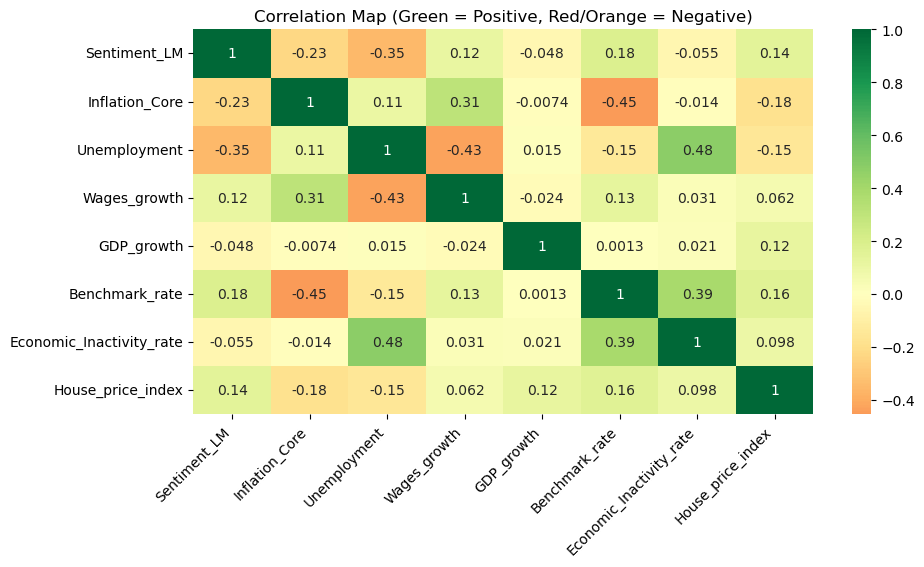

In [87]:
# Determine correlation
corr = variables_clean.corr(numeric_only=True)

# Create the correlation heatmap

plt.figure(figsize=(10, 5))
sns.heatmap(corr, annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Map (Green = Positive, Red/Orange = Negative)')
plt.xticks(rotation=45, ha='right')
plt.show()

## Sentiment vs Inflation

In [29]:
# Define the dependent variable.
y = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x = variables_clean['Inflation_Core'] 


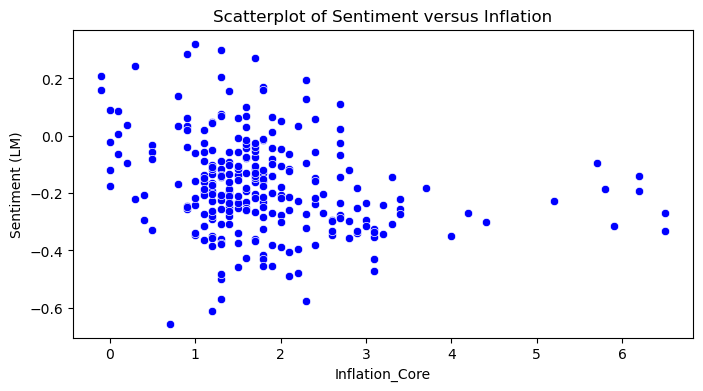

In [41]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus Inflation")
plt.xlabel("Inflation_Core")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "Inflation_Core",
               y= "Sentiment_LM",
               color = "blue")

plt.show()

In [39]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['Inflation_Core'], deg = 1)

# View output.
reg

array([-1.47267496,  1.53826707])

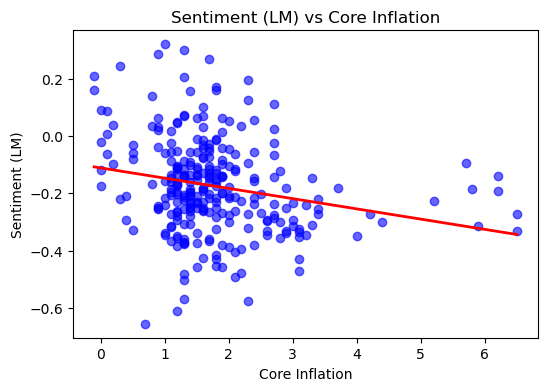

In [86]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend = np.polyval(reg, variables_clean['Inflation_Core'])

# View the previous scatterplot.
plt.figure(figsize=(6, 4), dpi=100)
sns.regplot(
    data=variables_clean,
    x='Inflation_Core',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Sentiment (LM) vs Core Inflation")
plt.xlabel("Core Inflation")
plt.ylabel("Sentiment (LM)")
plt.show()

In [44]:
# Pass linear regression through OLS methods.
test = ols('y ~ x', data = variables_clean).fit()

# Print the regression table.
test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.049
Method:                 Least Squares   F-statistic:                     15.00
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           0.000135
Time:                        18:11:12   Log-Likelihood:                 111.38
No. Observations:                 272   AIC:                            -218.8
Df Residuals:                     270   BIC:                            -211.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1115      0.019     -5.792      0.000      -0.149      -0.074
x             -0.0357      0.009     -3.873      0.000      -0.054      -0.018
==============================================================================
Omnibus:                        4.862   Durbin-Watson:                   1.501
Prob(Omnibus):                  0.088   Jarque-Bera (JB):                5.343
Skew:                           0.180   Prob(JB):                       0.0691
Kurtosis:                       3.584   Cond. No.                         4.84
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs Unemployment

In [45]:
# Define the dependent variable.
y2 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x2 = variables_clean['Unemployment'] 


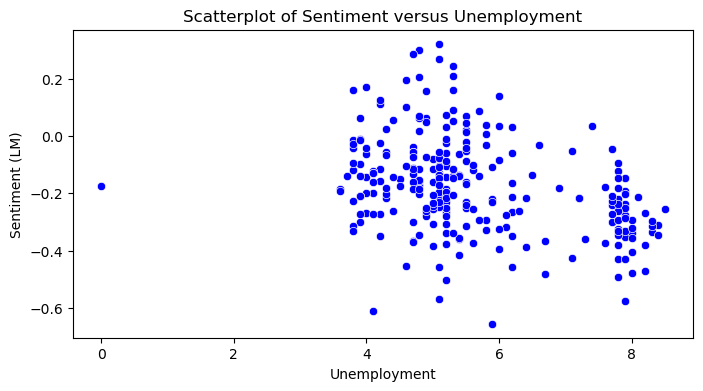

In [47]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "Unemployment",
               y= "Sentiment_LM",
               color = "blue")

plt.show()

In [48]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg2 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['Unemployment'], deg = 1)

# View output.
reg2

array([-2.94801833,  5.08709464])

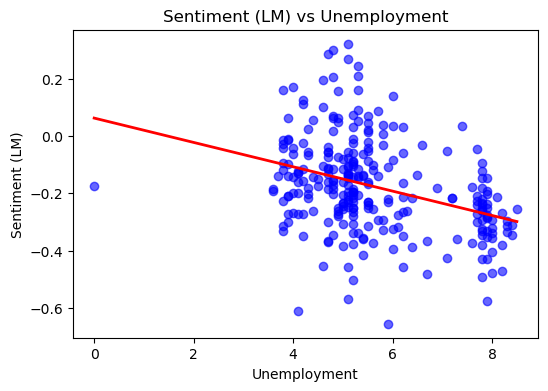

In [51]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend2 = np.polyval(reg2, variables_clean['Unemployment'])

# View the previous scatterplot.
plt.figure(figsize=(6, 4), dpi=100)
sns.regplot(
    data=variables_clean,
    x='Unemployment',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Sentiment (LM) vs Unemployment")
plt.xlabel("Unemployment")
plt.ylabel("Sentiment (LM)")
plt.show()

In [52]:
# Pass linear regression through OLS methods.
test2 = ols('y2 ~ x2', data = variables_clean).fit()

# Print the regression table.
test2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y2   R-squared:                       0.125
Model:                            OLS   Adj. R-squared:                  0.122
Method:                 Least Squares   F-statistic:                     38.62
Date:                Sun, 09 Nov 2025   Prob (F-statistic):           1.94e-09
Time:                        18:30:25   Log-Likelihood:                 122.21
No. Observations:                 272   AIC:                            -240.4
Df Residuals:                     270   BIC:                            -233.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0622      0.039      1.578      0.116      -0.015       0.140
x2            -0.0424      0.007     -6.214      0.000      -0.056      -0.029
==============================================================================
Omnibus:                        7.645   Durbin-Watson:                   1.616
Prob(Omnibus):                  0.022   Jarque-Bera (JB):                9.393
Skew:                           0.243   Prob(JB):                      0.00913
Kurtosis:                       3.769   Cond. No.                         24.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs Wages Growth

In [53]:
# Define the dependent variable.
y3 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x3 = variables_clean['Wages_growth']

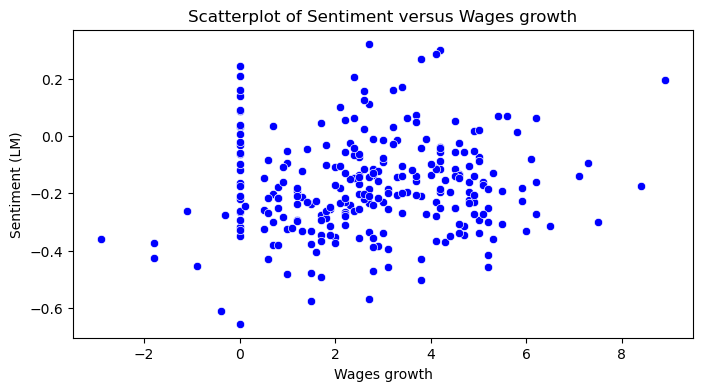

In [55]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus Wages growth")
plt.xlabel("Wages growth")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "Wages_growth",
               y= "Sentiment_LM",
               color = "blue")

plt.show()

In [56]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg3 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['Wages_growth'], deg = 1)

# View output.
reg3

array([1.3563323 , 2.96077344])

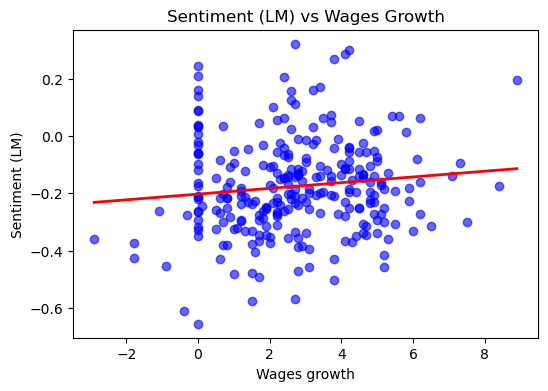

In [59]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend3 = np.polyval(reg3, variables_clean['Wages_growth'])

# View the previous scatterplot.
plt.figure(figsize=(6, 4), dpi=100)
sns.regplot(
    data=variables_clean,
    x='Wages_growth',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Sentiment (LM) vs Wages Growth")
plt.xlabel("Wages growth")
plt.ylabel("Sentiment (LM)")
plt.show()

In [60]:
# Pass linear regression through OLS methods.
test3 = ols('y3 ~ x3', data = variables_clean).fit()

# Print the regression table.
test3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y3   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.010
Method:                 Least Squares   F-statistic:                     3.701
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0554
Time:                        18:34:22   Log-Likelihood:                 105.88
No. Observations:                 272   AIC:                            -207.8
Df Residuals:                     270   BIC:                            -200.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2029      0.017    -11.740      0.000      -0.237      -0.169
x3             0.0100      0.005      1.924      0.055      -0.000       0.020
==============================================================================
Omnibus:                        8.717   Durbin-Watson:                   1.432
Prob(Omnibus):                  0.013   Jarque-Bera (JB):                8.780
Skew:                           0.379   Prob(JB):                       0.0124
Kurtosis:                       3.447   Cond. No.                         6.13
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs GDP Growth

In [61]:
# Define the dependent variable.
y4 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x4 = variables_clean['GDP_growth']

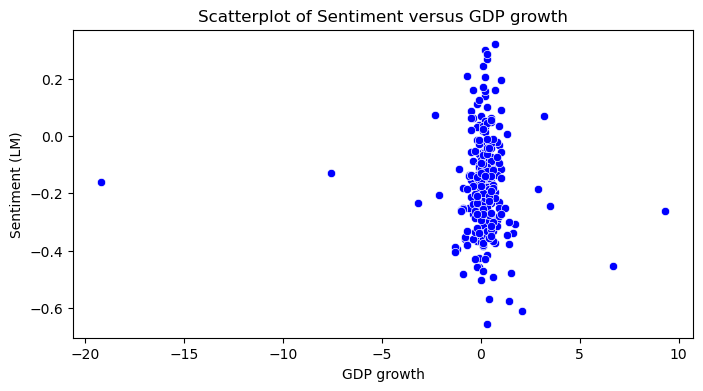

In [65]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus GDP growth")
plt.xlabel("GDP growth")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "GDP_growth",
               y= "Sentiment_LM",
               color = "blue")

plt.show()

In [66]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg4 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['GDP_growth'], deg = 1)

# View output.
reg4

array([-0.45606918,  0.06801717])

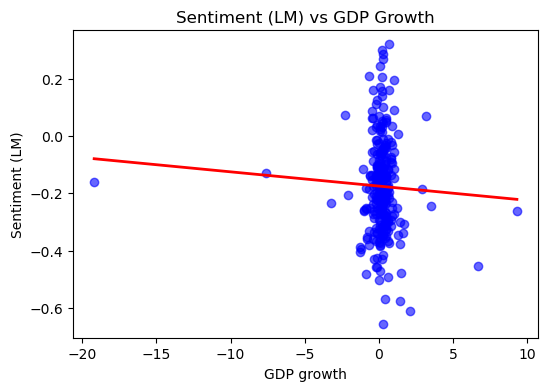

In [68]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend4 = np.polyval(reg4, variables_clean['GDP_growth'])

# View the previous scatterplot.
plt.figure(figsize=(6, 4), dpi=100)
sns.regplot(
    data=variables_clean,
    x='GDP_growth',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Sentiment (LM) vs GDP Growth")
plt.xlabel("GDP growth")
plt.ylabel("Sentiment (LM)")
plt.show()

In [69]:
# Pass linear regression through OLS methods.
test4 = ols('y4 ~ x4', data = variables_clean).fit()

# Print the regression table.
test4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y4   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.6134
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.434
Time:                        18:38:17   Log-Likelihood:                 104.34
No. Observations:                 272   AIC:                            -204.7
Df Residuals:                     270   BIC:                            -197.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1750      0.010    -17.363      0.000      -0.195      -0.155
x4            -0.0050      0.006     -0.783      0.434      -0.017       0.008
==============================================================================
Omnibus:                        7.571   Durbin-Watson:                   1.413
Prob(Omnibus):                  0.023   Jarque-Bera (JB):                7.609
Skew:                           0.337   Prob(JB):                       0.0223
Kurtosis:                       3.465   Cond. No.                         1.60
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs Benchmark rate

In [70]:
# Define the dependent variable.
y5 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x5 = variables_clean['Benchmark_rate']

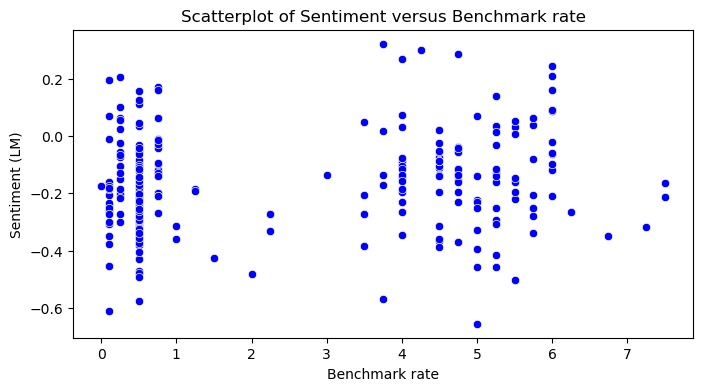

In [71]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus Benchmark rate")
plt.xlabel("Benchmark rate")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "Benchmark_rate",
               y= "Sentiment_LM",
               color = "blue")

plt.show()

In [72]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg5 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['Benchmark_rate'], deg = 1)

# View output.
reg5

array([2.52346774, 2.74271126])

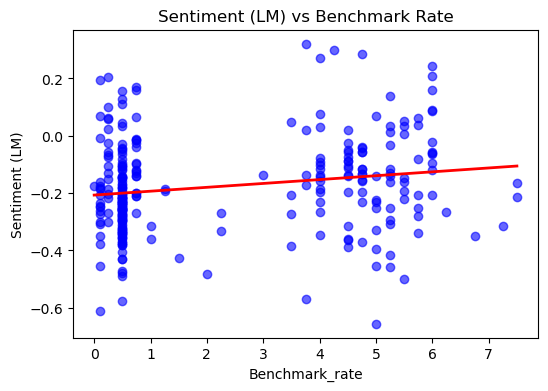

In [73]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend5 = np.polyval(reg5, variables_clean['Benchmark_rate'])

# View the previous scatterplot.
plt.figure(figsize=(6, 4), dpi=100)
sns.regplot(
    data=variables_clean,
    x='Benchmark_rate',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Sentiment (LM) vs Benchmark Rate")
plt.xlabel("Benchmark_rate")
plt.ylabel("Sentiment (LM)")
plt.show()

In [74]:
# Pass linear regression through OLS methods.
test5 = ols('y5 ~ x5', data = variables_clean).fit()

# Print the regression table.
test5.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y5   R-squared:                       0.034
Model:                            OLS   Adj. R-squared:                  0.030
Method:                 Least Squares   F-statistic:                     9.525
Date:                Sun, 09 Nov 2025   Prob (F-statistic):            0.00224
Time:                        18:40:34   Log-Likelihood:                 108.74
No. Observations:                 272   AIC:                            -213.5
Df Residuals:                     270   BIC:                            -206.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.2068      0.014    -14.670      0.000      -0.235      -0.179
x5             0.0135      0.004      3.086      0.002       0.005       0.022
==============================================================================
Omnibus:                        6.066   Durbin-Watson:                   1.468
Prob(Omnibus):                  0.048   Jarque-Bera (JB):                6.506
Skew:                           0.245   Prob(JB):                       0.0387
Kurtosis:                       3.579   Cond. No.                         4.84
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs Economic Inactivity rate

In [75]:
# Define the dependent variable.
y6 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x6 = variables_clean['Economic_Inactivity_rate']

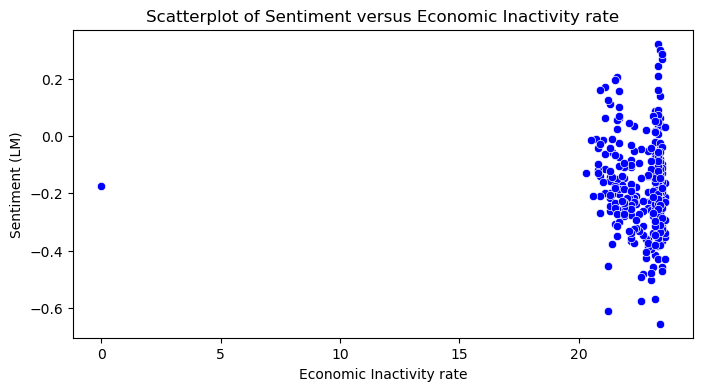

In [77]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus Economic Inactivity rate")
plt.xlabel("Economic Inactivity rate")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "Economic_Inactivity_rate",
               y= "Sentiment_LM",
               color = "blue")

plt.show()

In [78]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg6 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['Economic_Inactivity_rate'], deg = 1)

# View output.
reg6

array([-0.54249001, 22.40062463])

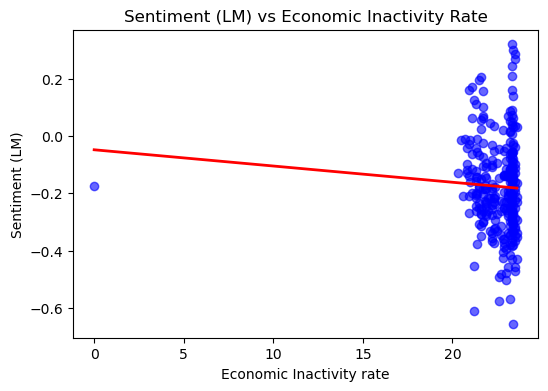

In [79]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend6 = np.polyval(reg6, variables_clean['Economic_Inactivity_rate'])

# View the previous scatterplot.
plt.figure(figsize=(6, 4), dpi=100)
sns.regplot(
    data=variables_clean,
    x='Economic_Inactivity_rate',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Sentiment (LM) vs Economic Inactivity Rate")
plt.xlabel("Economic Inactivity rate")
plt.ylabel("Sentiment (LM)")
plt.show()

In [80]:
# Pass linear regression through OLS methods.
test6 = ols('y6 ~ x6', data = variables_clean).fit()

# Print the regression table.
test6.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y6   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8321
Date:                Sun, 09 Nov 2025   Prob (F-statistic):              0.362
Time:                        18:43:58   Log-Likelihood:                 104.45
No. Observations:                 272   AIC:                            -204.9
Df Residuals:                     270   BIC:                            -197.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0483      0.140     -0.345      0.730      -0.324       0.227
x6            -0.0057      0.006     -0.912      0.362      -0.018       0.007
==============================================================================
Omnibus:                        7.947   Durbin-Watson:                   1.421
Prob(Omnibus):                  0.019   Jarque-Bera (JB):                8.110
Skew:                           0.341   Prob(JB):                       0.0173
Kurtosis:                       3.500   Cond. No.                         315.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## Sentiment vs House Price index

In [81]:
# Define the dependent variable.
y7 = variables_clean['Sentiment_LM'] 

# Define the independent variable.
x7 = variables_clean['House_price_index']

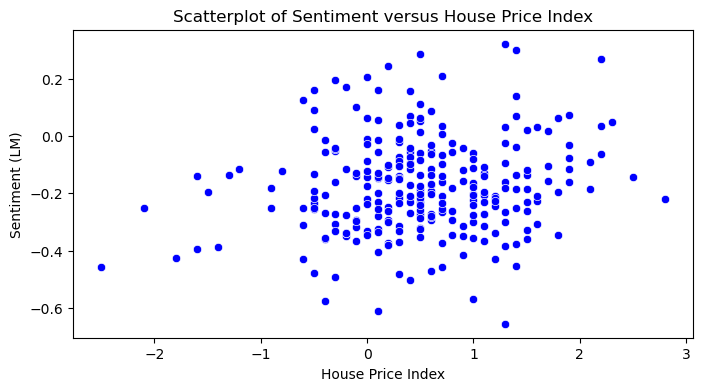

In [82]:
# Visualise the data (pre-regression)
# Start with a visualisation BEFORE running linear regression.
plt.figure(figsize=(8, 4), dpi=100)
# plt.figure(dpi=120)
plt.title("Scatterplot of Sentiment versus House Price Index")
plt.xlabel("House Price Index")
plt.ylabel("Sentiment (LM)")
sns.scatterplot(data=variables_clean,
               x= "House_price_index",
               y= "Sentiment_LM",
               color = "blue")

plt.show()

In [83]:
# Fit the linear model.
# Polyfit() good to use for simple linear regression (only one variable).
# Degree = 1, degree of polynomium, for SLR always 1.
reg7 = np.polyfit(variables_clean['Sentiment_LM'], variables_clean['House_price_index'], deg = 1)

# View output.
reg7

array([0.69219042, 0.61906443])

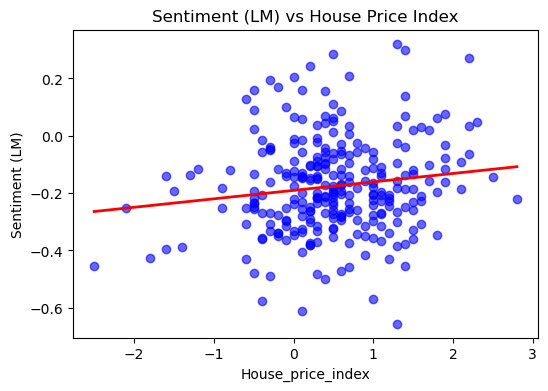

In [84]:
# Add a trendline to visualise the linear regression.
# Use the NumPy polyval method, specify the regression and the independent variable.
trend7 = np.polyval(reg7, variables_clean['House_price_index'])

# View the previous scatterplot.
plt.figure(figsize=(6, 4), dpi=100)
sns.regplot(
    data=variables_clean,
    x='House_price_index',
    y='Sentiment_LM',
    ci=None,  # removes confidence interval
    scatter_kws={'color': 'blue', 'alpha': 0.6},
    line_kws={'color': 'red', 'linewidth': 2}
)

plt.title("Sentiment (LM) vs House Price Index")
plt.xlabel("House_price_index")
plt.ylabel("Sentiment (LM)")
plt.show()

In [85]:
# Pass linear regression through OLS methods.
test7 = ols('y7 ~ x7', data = variables_clean).fit()

# Print the regression table.
test7.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     y7   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                  0.017
Method:                 Least Squares   F-statistic:                     5.627
Date:                Sun, 09 Nov 2025   Prob (F-statistic):             0.0184
Time:                        18:46:27   Log-Likelihood:                 106.83
No. Observations:                 272   AIC:                            -209.7
Df Residuals:                     270   BIC:                            -202.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.1904      0.012    -16.261      0.000      -0.213      -0.167
x7             0.0295      0.012      2.372      0.018       0.005       0.054
==============================================================================
Omnibus:                        7.703   Durbin-Watson:                   1.501
Prob(Omnibus):                  0.021   Jarque-Bera (JB):                7.869
Skew:                           0.332   Prob(JB):                       0.0196
Kurtosis:                       3.504   Cond. No.                         1.81
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

## **VADER sentiment analysis with LM Dictionary**

#### Outputs from this section:
- Financial sentiment analysis of BoE speeches (.csv and .xlsx)
    - Containing negative, positive and neutral scores
    - Compound, polarity, subjectivity, LM scores and LM label (e.g. negative)

In [5]:
# Load dataset. Change directory as required.
ukspeeches_df = pd.read_csv('../data_clean/uk_speeches.csv')

Updated 'df' variable name here to 'ukspeeches_df' to make it more unique

In [6]:
ukspeeches_df.head()

,reference,country,date,title,author,is_gov,text
0,r980915a_BOE,united kingdom,15/09/1998,Speech,george,0,"Thank you, Chairman. I'm actually very pleased..."
1,r981021b_BOE,united kingdom,21/10/1998,Britain in Europe,george,0,It's a great pleasure to be here in the beauti...
2,r981021a_BOE,united kingdom,21/10/1998,Impact of the recent turbulence in internation...,king,1,Few industries have suffered more from volatil...
3,r981101a_BOE,united kingdom,01/11/1998,"Economic policy, with and without forecasts",budd,0,My topic this evening is the use of forecasts ...
4,r981101b_BOE,united kingdom,01/11/1998,Inflation targeting in practice: the UK experi...,vickers,0,"Six years ago this week, sterling left the exc..."


In [7]:
ukspeeches_df.country.value_counts()

country
united kingdom    1190
Name: count, dtype: int64

In [8]:
# Add a column to calculate the string length per speech.
ukspeeches_df['len'] = ukspeeches_df['text'].str.len()
ukspeeches_df

,reference,country,date,title,author,is_gov,text,len
0,r980915a_BOE,united kingdom,15/09/1998,Speech,george,0,"Thank you, Chairman. I'm actually very pleased...",13731
1,r981021b_BOE,united kingdom,21/10/1998,Britain in Europe,george,0,It's a great pleasure to be here in the beauti...,24263
2,r981021a_BOE,united kingdom,21/10/1998,Impact of the recent turbulence in internation...,king,1,Few industries have suffered more from volatil...,13678
3,r981101a_BOE,united kingdom,01/11/1998,"Economic policy, with and without forecasts",budd,0,My topic this evening is the use of forecasts ...,27679
4,r981101b_BOE,united kingdom,01/11/1998,Inflation targeting in practice: the UK experi...,vickers,0,"Six years ago this week, sterling left the exc...",27693
...,...,...,...,...,...,...,...,...
1185,r221007a_BOE,united kingdom,07/10/2022,"Shocks, inflation, and the policy response",ramsden,0,Thank you very much for the invitation to spea...,24773
1186,r221012a_BOE,united kingdom,12/10/2022,Monetary policy: an anchor in challenging times,pill,0,Huw Pill talks about how we will bring inflati...,22398
1187,r221015a_BOE,united kingdom,15/10/2022,Monetary policy and financial stability interv...,bailey,1,We are meeting in the most difficult of times....,10270
1188,r221019a_BOE,united kingdom,19/10/2022,"Governance of “Decentralised” Finance: Get up,...",wilkins,0,"These are divided into seven categories, suffr...",32759


In [10]:
# Text cleaning
ukspeeches_df['text'] = ukspeeches_df['text'].str.lower().str.replace(r'[^\w\s]', '', regex=True)

In [11]:
# VADER sentiment
sia = SentimentIntensityAnalyzer()
ukspeeches_df[['neg', 'neu', 'pos', 'compound']] = ukspeeches_df['text'].apply(lambda x: pd.Series(sia.polarity_scores(x)))

<div class="alert alert-block alert-warning">
^ Code block runtime on M1 MacBook Air (2020): 4m 5s

In [15]:
# TextBlob sentiment
ukspeeches_df[['polarity','subjectivity']] = ukspeeches_df['text'].apply(lambda x: pd.Series(TextBlob(x).sentiment))

In [16]:
# Load Loughran–McDonald Dictionary
lm_dict = pd.read_csv("../data_clean/LM_dictionary.csv")  
print("LM Columns:", lm_dict.columns)  # check columns

LM Columns: Index(['Word', 'Negative', 'Positive', 'Uncertainty', 'Litigious', 'Strong',
       'Weak', 'Constraining'],
      dtype='object')


In [17]:
# Create a mapping: Word -> list of categories
lm_dict_map = {}
for _, row in lm_dict.iterrows():
    word = row['Word'].upper()
    categories = [col for col in lm_dict.columns[1:] if row[col] > 0]  # skip 'Word' column
    lm_dict_map[word] = categories

In [18]:
# Function to compute LM sentiment
def lm_sentiment(text, lm_dict_map):
    words = re.findall(r'\b\w+\b', text.upper())
    pos = sum(1 for w in words if 'Positive' in lm_dict_map.get(w, []))
    neg = sum(1 for w in words if 'Negative' in lm_dict_map.get(w, []))
    total = pos + neg
    return 0 if total == 0 else (pos - neg)/total

In [19]:
# Apply LM sentiment
ukspeeches_df['lm_score'] = ukspeeches_df['text'].apply(lambda x: lm_sentiment(x, lm_dict_map))

In [20]:
# Combined Score (simple average)
ukspeeches_df['combined_score'] = (ukspeeches_df['compound'] + ukspeeches_df['polarity'] + ukspeeches_df['lm_score']) / 3

In [21]:
# LM Label Thresholds
def lm_label(score, pos_thresh=0.05, neg_thresh=-0.05):
    """
    Assigns a sentiment label based on LM score thresholds.
    
    Parameters:
        score: LM sentiment score ([-1,1])
        pos_thresh: threshold above which text is Positive
        neg_thresh: threshold below which text is Negative
        
    Returns:
        'Positive', 'Negative', or 'Neutral'
    """
    if score > pos_thresh:
        return "Positive"
    elif score < neg_thresh:
        return "Negative"
    else:
        return "Neutral"
    
ukspeeches_df['lm_label'] = ukspeeches_df['lm_score'].apply(lambda x: lm_label(x))    

# Export Selected Columns
columns_to_export = [
    'reference','date','text', 
    'neg', 'neu', 'pos', 'compound', 
    'polarity', 'subjectivity', 
    'lm_score', 
    'combined_score', 
    'lm_label'
]

In [22]:
# Export CSV
ukspeeches_df.to_csv("../data_output/financial_sentiment_labeled.csv", columns=columns_to_export, index=False, encoding='utf-8')

In [23]:
# Export Excel
ukspeeches_df.to_excel("../data_output/financial_sentiment_labeled.xlsx", columns=columns_to_export, index=False, sheet_name="Sentiment")

## **FinBERT sentiment analysis**

***

## **Financial Stability Report sentiment analysis**

***

## **Monetary Policy / Inflation Report sentiment analysis**

***